---
title: "Tutorial 6 (Advanced): Linking Brain to Phenotypes (Part 3: Machine Learning)"
authors:
  - name: Sapolnach Prompiengchai
    affiliations:
      - University of Oxford
  - name: Aarushi Vardhan
    affiliations:
      - University of Toronto / University of Cambridge
---


# From association to prediction

In Tutorial 5, we asked whether age and functional connectivity (FC) were **associated**. In this tutorial, we ask a different question:

> **Can patterns of functional connectivity help us distinguish younger from older adults in participants the model has not seen before?**

That last phrase — *participants the model has not seen before* — is the central idea of this tutorial. A machine-learning model is useful only if it can apply what it learned to new examples, rather than simply remembering the people it trained on.

This is a **supervised machine-learning classification** problem:

- **supervised** means that, while training, the model sees examples for which we already know the answer;
- **classification** means that the answer is a category — here, younger or older — rather than a continuous number.

You do **not** need previous machine-learning or scikit-learn experience. We will build the workflow one idea at a time and explain what the code is doing.

By the end of the tutorial, you should be able to explain:

- what **samples**, **features**, and a **target** are;
- what it means to **fit** a model and ask it to **predict**;
- why we keep training and test participants separate;
- how 5-fold cross-validation works;
- what `StandardScaler`, a scikit-learn `Pipeline`, and logistic regression each do;
- why preprocessing can cause **data leakage** if it is done in the wrong order;
- why class imbalance changes how we evaluate a model;
- how to read accuracy, balanced accuracy, a confusion matrix, an ROC curve, and ROC AUC; and
- how to interpret a predictive result without turning it into a causal or clinical claim.

```{important}
This tutorial uses the FC matrices created in Tutorial 2 and the cleaned metadata and network labels created earlier in the workflow. The machine-learning steps below assume those files already exist.
```


## A map of the workflow

Before writing code, it helps to see the whole journey. We'll use an example of trying to use FC features to predict whether someone is young or old. We will repeatedly return to this map:

```text
1. QUESTION
   Can FC distinguish younger from older participants?
          |
          v
2. REPRESENT EACH PARTICIPANT WITH NUMBERS
   28 network-level FC features
          |
          v
3. GIVE THE MODEL EXAMPLES WITH KNOWN ANSWERS
   X = FC features      y = age-group labels
          |
          v
4. LET THE MODEL LEARN FROM TRAINING PARTICIPANTS
   standardize features -> fit logistic regression
          |
          v
5. TEST ON PARTICIPANTS THAT WERE HELD OUT (i.e., new sets of participants that 
the model hasn't seen)
   predictions -> evaluation metrics
          |
          v
6. REPEAT WITH CROSS-VALIDATION
   every participant is tested once
```

Machine learning can feel complicated because many new terms appear at once. Most of them describe one of these six steps.


## 1. Translate the neuroscience question into machine-learning language

A machine-learning program does not understand the phrase “brain connectivity” by itself. We have to tell it what one example looks like and what answer we want it to learn.

| Machine-learning term | In this tutorial |
|---|---|
| **Sample** | one participant |
| **Features (`X`)** | 28 FC summary values measured for that participant |
| **Target (`y`)** | that participant's age group: younger (`0`) or older (`1`) |

Think of a spreadsheet. Each **row** is one participant. Each **column** in `X` is one measurable clue the model can use.

```text
                         FEATURES (X)                         TARGET (y)
Participant      Visual-within   DMN-within   ...          Age group
     1                0.42          0.31      ...          Younger (0)
     2                0.38          0.47      ...          Older   (1)
     3                0.51          0.29      ...          Younger (0)
```

The target (i.e., age group) has two categories, so this is a **classification** problem. If we instead asked the model to predict exact age in years, that would be a **regression** problem. Similar concepts apply to both classification and regression machine learning. 

### Scikit-learn #1: objects learn when we call `.fit()`

We will use the Python library **scikit-learn**. A useful logic for you is:

- writing `LogisticRegression()` creates a model *recipe*;
- calling `.fit(X_train, y_train)` lets that model learn from training examples;
- calling `.predict(X_test)` asks the fitted model for class predictions on new examples;
- calling `.predict_proba(X_test)` asks for estimated probabilities instead of only class labels.

The same pattern appears throughout scikit-learn. Preprocessing tools also have a `.fit()` step because some preprocessing operations learn information from the data.


In [9]:
# Import the Python tools used in this tutorial.
# An import makes a function or class available; it does not fit a model yet.

from itertools import combinations
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# scikit-learn tools for models, preprocessing, evaluation, and cross-validation
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    accuracy_score,
    balanced_accuracy_score,
    confusion_matrix,
    roc_auc_score,
)
from sklearn.model_selection import (
    StratifiedKFold,
    cross_validate,
    cross_val_predict,
    permutation_test_score,
)
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler


# Option 1: use the current working directory if the notebook is inside the project folder
# PROJECT_DIR = Path.cwd()

# Option 2: manually specify your project directory if needed
PROJECT_DIR = Path(
    "/Users/shemrock/Library/CloudStorage/OneDrive-Nexus365/Clematis/guide/Conn_comp/competition2026/lemon2026"
)

RESULTS_DIR = PROJECT_DIR / "results"
PROCESSED_DIR = PROJECT_DIR / "processed_data"


The import cell contains many names, but you do not need to memorize them. We will introduce each important one when it first appears.

`PROJECT_DIR` tells Python where the project lives. The next cell then builds the expected file paths and loads the outputs created in earlier tutorials.


In [10]:
# Load the outputs created in earlier tutorials.
# We store the expected paths in a dictionary so that missing files are easy to report.

required_files = {
    "FC matrices": RESULTS_DIR / "subject_fc_stack.npy",
    "participant IDs": RESULTS_DIR / "subject_ids.npy",
    "region names": RESULTS_DIR / "region_names.npy",
    "cleaned metadata": PROCESSED_DIR / "lemon_analysis_metadata.csv",
    "network indices": PROCESSED_DIR / "network_region_indices.npy",
}

missing_files = [str(path) for path in required_files.values() if not path.exists()]
if missing_files:
    raise FileNotFoundError(
        "Some required files are missing. Run the earlier tutorials first and check "
        f"PROJECT_DIR. Missing files: {missing_files}"
    )

fc_stack = np.load(required_files["FC matrices"])
subject_ids = np.load(required_files["participant IDs"], allow_pickle=True).astype(str)
region_names = np.load(required_files["region names"], allow_pickle=True).astype(str)
analysis_meta = pd.read_csv(required_files["cleaned metadata"])
loaded_network_indices = np.load(required_files["network indices"], allow_pickle=True).item()
net_to_idx = {
    str(name): np.asarray(indices)
    for name, indices in loaded_network_indices.items()
}

print(f"FC array: {fc_stack.shape}  (participants x regions x regions)")
print(f"Metadata table: {analysis_meta.shape[0]} participants x {analysis_meta.shape[1]} columns")
print(f"Networks: {list(net_to_idx)}")


FC array: (220, 100, 100)  (participants x regions x regions)
Metadata table: 220 participants x 12 columns
Networks: ['Visual', 'SMN', 'DAN', 'VAN', 'Limbic', 'FPN', 'DMN']


## 2. Audit the data before modelling

Machine-learning code can run even when the rows are paired incorrectly. That is dangerous: participant 1's FC matrix must be matched with participant 1's metadata and age label.

An `assert` statement is a safety check. If its condition is false, Python stops instead of silently continuing with misaligned data.


In [11]:
# Check that all files refer to participants in exactly the same order.

metadata_ids = analysis_meta["subject_id"].astype(str).to_numpy()

assert len(fc_stack) == len(subject_ids) == len(analysis_meta)
assert np.array_equal(subject_ids, metadata_ids)
assert fc_stack.shape[1] == fc_stack.shape[2] == len(region_names)

print("Alignment checks passed.")


Alignment checks passed.


In [12]:
# Inspect the target variable and possible missing values.

print("Age-group counts (including missing values):")
display(analysis_meta["age_group"].value_counts(dropna=False).rename("participants"))

usable_meta = analysis_meta[analysis_meta["age_group"].isin(["Young", "Old"])]

print("\nSex composition within each age group:")
display(
    pd.crosstab(
        usable_meta["age_group"],
        usable_meta["sex"],
        normalize="index",
    ).round(3)
)


Age-group counts (including missing values):


age_group
Young    151
Old       68
NaN        1
Name: participants, dtype: int64


Sex composition within each age group:


sex,Female,Male
age_group,,
Old,0.471,0.529
Young,0.298,0.702


One participant has no age-group label, so that participant cannot be used for this supervised-learning task. We will exclude that row when we construct `X` and `y`.

The sex proportions also differ between age groups. That matters for interpretation. If sex is related to FC, then some of the pattern used by the classifier could reflect sex differences that happen to line up with the age groups. This is a possible **confound**, and we return to it later.

The lesson is simple: machine learning does not make data-quality problems disappear. It can learn any systematic pattern that helps prediction, including patterns we did not intend it to use.


## 3. Turn each connectome into a manageable set of features

Each participant has a 100 x 100 symmetric FC matrix. Because the matrix is symmetric, the connection from region A to region B is the same as the connection from B to A. Ignoring the diagonal, the number of unique edges is

$$
\frac{100(100-1)}{2}=4,950.
$$

We *could* give all 4,950 edges to a model. But we have only 219 participants with age labels. That means there would be far more features than participants. Such models are possible, especially with careful regularization, but they are easier to overfit and harder to explain in an introductory tutorial.

For this analysis, we therefore compress each connectome into **28 interpretable network-level features**:

- 7 mean within-network FC values; and
- 21 mean between-network FC values, one for each pair among 7 networks.

So instead of describing one participant with 4,950 edge values, we describe that participant with 28 network summaries.

### Fisher transformation happens within one participant

Before averaging correlation coefficients, we apply the **Fisher z transformation** introduced earlier. This transformation acts on each correlation value in one participant's FC matrix. It does not look across participants and it does not use age labels.

For example, a participant's “DMN-FPN” feature is created by Fisher-transforming the relevant correlations in *that participant's* matrix and then averaging those transformed values.


In [13]:
# Fisher z-transform each participant's FC matrix.
# Clipping avoids infinite values if rounding produces exactly -1 or +1.

z_fc_stack = np.arctanh(np.clip(fc_stack, -0.999999, 0.999999))

network_names = list(net_to_idx)
feature_data = {}

# Seven within-network features.
# We use only the upper triangle so each edge is counted once and the diagonal is excluded.
for network in network_names:
    indices = np.asarray(net_to_idx[network])
    block = z_fc_stack[:, indices[:, None], indices[None, :]]
    upper = np.triu_indices(len(indices), k=1)
    feature_data[f"{network} within"] = block[:, upper[0], upper[1]].mean(axis=1)

# Twenty-one between-network features.
for network_a, network_b in combinations(network_names, 2):
    indices_a = np.asarray(net_to_idx[network_a])
    indices_b = np.asarray(net_to_idx[network_b])
    block = z_fc_stack[:, indices_a[:, None], indices_b[None, :]]
    feature_data[f"{network_a}-{network_b}"] = block.mean(axis=(1, 2))

feature_df = pd.DataFrame(feature_data, index=subject_ids)

print(f"Feature table: {feature_df.shape[0]} participants x {feature_df.shape[1]} features")
display(feature_df.head())


Feature table: 220 participants x 28 features


,Visual within,SMN within,DAN within,VAN within,Limbic within,FPN within,DMN within,Visual-SMN,Visual-DAN,Visual-VAN,...,DAN-VAN,DAN-Limbic,DAN-FPN,DAN-DMN,VAN-Limbic,VAN-FPN,VAN-DMN,Limbic-FPN,Limbic-DMN,FPN-DMN
sub-010002,0.554779,0.352086,0.464045,0.520293,0.445534,0.447956,0.581784,0.202107,0.215025,0.248702,...,0.343796,0.133319,0.260103,0.108935,-0.043792,0.119150,-0.086467,0.295524,0.408054,0.312074
sub-010003,0.706880,0.718268,0.801581,0.576414,0.628380,0.457207,0.562480,0.394337,0.501957,0.264876,...,0.377402,0.193565,0.439461,0.149229,0.109112,0.225413,0.101217,0.222850,0.464160,0.314418
sub-010004,0.880350,1.111750,0.532303,1.006087,0.521755,0.385237,0.407310,0.392440,0.431982,0.528436,...,0.523610,0.238724,0.238931,0.157811,0.285416,0.289268,0.159413,0.201821,0.366773,0.153474
sub-010005,0.994483,1.226059,0.969323,0.808755,0.967577,0.718074,0.695631,0.689396,0.752375,0.493310,...,0.654000,0.294603,0.455569,0.339854,0.390425,0.463194,0.444814,0.470247,0.684323,0.575035
sub-010006,0.645406,1.102473,0.805499,0.811506,0.696911,0.845792,0.676291,0.302875,0.438020,0.499456,...,0.592793,0.484886,0.287016,0.339273,0.488865,0.587455,0.393961,0.476834,0.585582,0.545378


The table above is now in the shape machine-learning libraries expect: rows are participants and columns are features.

Next we create the two objects used by nearly every supervised scikit-learn model:

- `X`: the feature matrix;
- `y`: the target labels.

In this tutorial, `0` means younger and `1` means older. The numbers are only computer-friendly labels; they do not imply that one group is more important than the other.


In [14]:
# Build X (features) and y (target), excluding the participant with no age-group label.

valid_age = analysis_meta["age_group"].isin(["Young", "Old"]).to_numpy()

X = feature_df.to_numpy()[valid_age]
y = (
    analysis_meta.loc[valid_age, "age_group"] == "Old"
).astype(int).to_numpy()
model_subject_ids = subject_ids[valid_age]

assert len(X) == len(y) == len(model_subject_ids)
assert np.isfinite(X).all()

class_table = pd.DataFrame(
    {
        "class label": [0, 1],
        "age group": ["Younger", "Older"],
        "participants": np.bincount(y),
    }
)

display(class_table)
print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")


,class label,age group,participants
0,0,Younger,151
1,1,Older,68


X shape: (219, 28)
y shape: (219,)


In [ ]:
y # 0 and 1 -> age group for each of the 219 partciipants

array([1, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0,
       1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0,
       0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0,
       0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0,
       1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

### Pause and predict

Before fitting anything, answer these questions in words:

1. There are 151 younger and 68 older participants. If a program predicts “younger” for everybody, what ordinary accuracy would it obtain?
2. Would that program have learned anything from FC?
3. If we want to know whether a model can help with *new* participants, should we judge it on people it learned from or people it did not learn from?

Keep those answers in mind. They motivate almost every design choice below.


## 4. How logistic regression turns features into a prediction

We will use **logistic regression** as our first classifier. The name is confusing: despite the word *regression*, logistic regression is commonly used to predict one of two classes.

### First, an everyday analogy

Imagine a simple weather app deciding whether tomorrow is likely to be rainy. It might use clues such as cloud cover, humidity, and air pressure. It does not need a rule like:

> “If humidity is above exactly 73%, predict rain.”

Instead, each clue can contribute some amount of evidence. Cloud cover might push the prediction toward rain, while high pressure might push it away from rain. The app combines those contributions into one overall score.

Logistic regression does the same thing. In our case:

- the **28 FC features** are the clues;
- the model learns a **weight**, also called a coefficient, for each clue;
- the weighted clues are added together to make one score;
- that score is converted into a probability between 0 and 1.

### Step 1: make a weighted score

For 28 features, the model computes

$$
s=b_0+b_1x_1+b_2x_2+\cdots+b_{28}x_{28}.
$$

You can read this equation as:

> **starting value + contribution from feature 1 + contribution from feature 2 + ...**

Here, `x` values are one participant's features and the `b` values are weights learned from the training data.

A positive contribution pushes the score toward class `1` (older). A negative contribution pushes it toward class `0` (younger).

### An example using 2 FC features 

Pretend for a moment that we have only two standardized FC features. Suppose a fitted model learned

$$
s=0 + 1.0x_1 - 0.5x_2.
$$

For a participant with $x_1=1$ and $x_2=-1$,

$$
s=1.0(1)-0.5(-1)=1.5.
$$

The first feature contributes evidence toward the older class. Because the second feature is below average and has a negative weight, it also pushes the score upward in this example. Real models use all 28 features at once.

### Step 2: turn the score into a probability

The raw score can be any number from negative to positive infinity. Logistic regression passes it through the **sigmoid function**:

$$
P(\mathrm{older})=\frac{1}{1+e^{-s}}.
$$

You do not need to calculate this by hand. The important idea is what the function does:

| Weighted score `s` | Approximate probability of older |
|---:|---:|
| -2 | 0.12 |
| 0 | 0.50 |
| +2 | 0.88 |

So very negative scores become probabilities near 0, a score of 0 becomes 0.50, and very positive scores become probabilities near 1.

With the usual 0.50 decision threshold:

- probability >= 0.50 -> predict older;
- probability < 0.50 -> predict younger.

The model is **not** given a neuroscientific rule such as “low DMN connectivity means older.” During `.fit()`, it learns the combination of weights that best separates the labelled training examples.


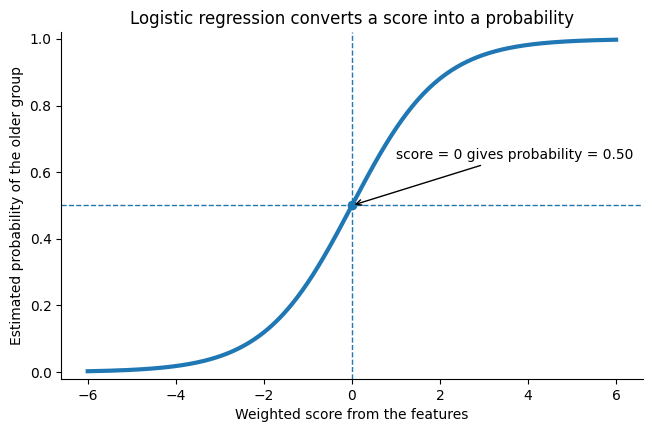

In [ ]:
# Visualize the sigmoid function used by logistic regression.
# NOTE: I've coded this to illustrate logistic regression. It does not fit our FC model yet.

weighted_score = np.linspace(-6, 6, 400)
probability_older = 1 / (1 + np.exp(-weighted_score))

fig, ax = plt.subplots(figsize=(7.5, 4.5))
ax.plot(weighted_score, probability_older, linewidth=3)
ax.axhline(0.5, linestyle="--", linewidth=1)
ax.axvline(0, linestyle="--", linewidth=1)
ax.scatter([0], [0.5], zorder=3)
ax.annotate(
    "score = 0 gives probability = 0.50",
    xy=(0, 0.5),
    xytext=(1.0, 0.64),
    arrowprops={"arrowstyle": "->"},
)
ax.set(
    xlabel="Weighted score from the features",
    ylabel="Estimated probability of the older group",
    ylim=(-0.02, 1.02),
    title="Logistic regression converts a score into a probability",
)
ax.spines[["top", "right"]].set_visible(False)
plt.show()


### Why start with logistic regression?

Logistic regression is a useful **starting model**, not automatically the best possible model.

It fits this tutorial well because our target has two classes, our features are numerical, and the model gives us both probabilities and interpretable coefficient directions. It is also relatively simple compared with highly flexible nonlinear algorithms, which is useful when the sample is modest.

One assumption is that the **log-odds** of the older class change linearly with the features. You do not need to work with log-odds directly here. The practical consequence is that logistic regression builds its decision from a weighted sum rather than learning arbitrary curves and interactions.

More complex models can be explored later, but they must be evaluated with the same care.


## 5. Before fitting the model: put features on comparable scales

The 28 features are all FC summaries, but they can still have different means and different amounts of variation. This matters because we will use L2 regularization, which penalizes coefficient size. It is easier to compare and regularize coefficients when one unit has a similar meaning across features. [For now, no need to understand what regularization does.]

To address the issue of each feature having different means and standard deviation, we therefore use scikit-learn's `StandardScaler`.

### What does `StandardScaler` do?

A scaler is a preprocessing tool that changes the numerical scale of features before they are given to a machine-learning model.

For example, imagine two features:

- Feature A ranges from 0.2 to 0.8
- Feature B ranges from 20 to 200

Their numbers are on very different scales. A scaler transforms them so they are represented more comparably.

`StandardScaler` is one particular type of scaler. 

For each feature, it calculates the mean and standard deviation from the training participants, then transforms the values so that the training data have approximately:

- mean = 0
- standard deviation = 1

So, in other words, for **each feature separately**, the scaler calculates two numbers from the training participants:

1. the feature's mean;
2. the feature's standard deviation (SD), which describes its spread.

It then transforms a value using

$$
x_{\mathrm{scaled}}=\frac{x-\mu_{\mathrm{training}}}{\sigma_{\mathrm{training}}}.
$$

In words:

> **subtract the training mean, then divide by the training SD.**

Suppose the training participants have a mean DMN-within FC of 0.40 and an SD of 0.10.

- FC = 0.40 becomes 0: exactly at the training mean.
- FC = 0.50 becomes +1: one training SD above the mean.
- FC = 0.60 becomes +2: two training SDs above the mean.
- FC = 0.30 becomes -1: one training SD below the mean.

Standardization does **not** mean that every participant becomes the same. It simply expresses each feature in units of its training-set spread.

### `fit`, `transform`, and `fit_transform`

Here,

```python
scaler = StandardScaler()
```

creates an empty scaler. It has not calculated any means or SDs yet.

```python
scaler.fit(X_train)
```

calculates the means and SDs from `X_train`.

```python
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)
```

uses those already-learned training values to transform both sets.

`fit_transform(X_train)` is simply a convenient way to fit on the training data and transform the training data in one step.


### Fisher *z* transformation and standardization are different

The word *z* appears in both contexts, which can be confusing.

| Operation | Acts on | Uses info from other participants? | Purpose here |
|---|---|---:|---|
| Fisher *z* transformation | each correlation edge | No | make correlations more suitable for averaging |
| `StandardScaler` | each final feature column | Yes, from training participants | express features in comparable training-set units |

Creating the 28 FC summaries before cross-validation is safe because each participant's summary uses only that participant's FC matrix plus the predefined atlas. Standardization is different because the mean and SD are calculated **across people**.


## 6. A scikit-learn pipeline: make preprocessing part of the model

We want every prediction to follow the same recipe:

```text
raw 28 FC features
        |
        v
StandardScaler
        |
        v
logistic regression
        |
        v
probability / predicted class
```

scikit-learn calls this chain a **pipeline**.

A pipeline is useful because we can treat the whole sequence like one model. If we later write

```python
model.fit(X_train, y_train)
```

scikit-learn will fit the scaler on `X_train`, transform `X_train`, and then fit logistic regression on the scaled training features.

If we then write

```python
model.predict(X_test)
```

scikit-learn will use the **already-fitted training scaler** to transform `X_test`, then pass the transformed values to the fitted classifier. It does not relearn the scaler from the test participants.


In [16]:
# Define the modelling recipe.
# At this point, these objects are configured but NOT yet fitted to our data.

model = make_pipeline(
    StandardScaler(),
    LogisticRegression(
        C=1.0,                 # inverse regularization strength; fixed in advance
        class_weight="balanced",
        max_iter=5000,
    ),
)

# A deliberately simple comparison model that ignores FC and predicts the most common class.
baseline = DummyClassifier(strategy="most_frequent")

model


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('standardscaler', ...), ('logisticregression', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some 

If Jupyter displays something like

```text
Pipeline(steps=[('standardscaler', StandardScaler()),
                ('logisticregression', LogisticRegression(...))])
```

that is only the **recipe**. No coefficients have been learned yet because we have not called `.fit()`.

This distinction is important for reading machine-learning code:

- creating/configuring an object is not training;
- `.fit(...)` is the step where information is learned from data.


## 7. Training, testing, and overfitting

Imagine revising for an exam using a set of practice questions. If someone asks how well you learned the material, scoring yourself on those exact same practice questions is not a strong test. You may remember details of those questions without being able to solve new ones.

A machine-learning model can have the same problem.

### Training participants

These participants are like the practice set. Their FC features **and** age-group labels are available to the model during fitting. Logistic regression adjusts its coefficients using these examples.

### Test participants

These participants are like unseen exam questions. Their features are given to the already-fitted model, but they were not used to learn the coefficients. Their true labels are revealed only for evaluation.

If a model performs very well on training participants but poorly on new participants, it has **overfit**: it learned patterns that were useful for reproducing the training sample but did not generalize well.

The important scientific quantity is therefore not “How well can the model describe the people it learned from?” but:

> **How well does it predict people that did not participate in fitting?**


### Why use cross-validation instead of one train/test split?

With only 219 labelled participants, one split can be unlucky. Perhaps the test set happens to contain unusually easy or difficult cases.

In **5-fold cross-validation**, we divide the data into five groups, called **folds**, and repeat the train/test process five times:

1. test on Fold 1, train on Folds 2-5;
2. test on Fold 2, train on the other four folds;
3. continue until each fold has been the test fold once.

This fits **five separate models**. Within any one round, a participant is either training or test — never both.

We use **stratified** folds, meaning that each fold keeps approximately the same younger/older proportion as the full dataset.


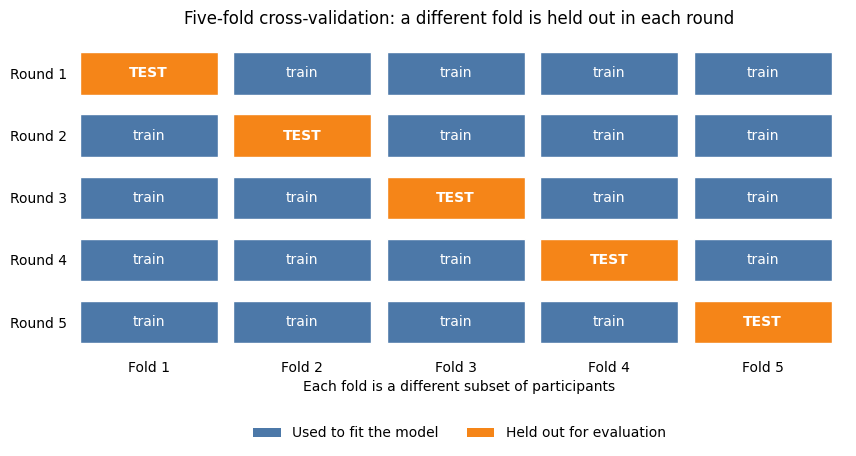

In [17]:
# Visual explanation of 5-fold cross-validation.
# Blue boxes are used for fitting in that round; orange boxes are held out for testing.

from matplotlib.patches import Patch, Rectangle

n_folds = 5
train_colour = "#4C78A8"
test_colour = "#F58518"

fig, ax = plt.subplots(figsize=(10, 4.2))

for round_index in range(n_folds):
    y_position = n_folds - 1 - round_index
    for fold_index in range(n_folds):
        is_test = fold_index == round_index
        colour = test_colour if is_test else train_colour
        label = "TEST" if is_test else "train"
        box = Rectangle(
            (fold_index, y_position),
            0.9,
            0.68,
            facecolor=colour,
            edgecolor="white",
        )
        ax.add_patch(box)
        ax.text(
            fold_index + 0.45,
            y_position + 0.34,
            label,
            ha="center",
            va="center",
            color="white",
            fontsize=10,
            fontweight="bold" if is_test else "normal",
        )

ax.set_xlim(-0.05, n_folds)
ax.set_ylim(-0.2, n_folds)
ax.set_xticks(np.arange(n_folds) + 0.45, [f"Fold {i}" for i in range(1, 6)])
ax.set_yticks(np.arange(n_folds) + 0.34, [f"Round {i}" for i in range(5, 0, -1)])
ax.set_title("Five-fold cross-validation: a different fold is held out in each round")
ax.set_xlabel("Each fold is a different subset of participants")
ax.legend(
    handles=[
        Patch(facecolor=train_colour, label="Used to fit the model"),
        Patch(facecolor=test_colour, label="Held out for evaluation"),
    ],
    loc="upper center",
    bbox_to_anchor=(0.5, -0.18),
    ncol=2,
    frameon=False,
)
for spine in ax.spines.values():
    spine.set_visible(False)
ax.tick_params(length=0)
plt.show()


We now tell scikit-learn how to make those folds. `StratifiedKFold` is not a model. It is a **splitting plan**.

`shuffle=True` mixes the participant order before making folds, and `random_state=42` makes that shuffle reproducible. The number 42 has no scientific meaning; using a fixed value simply means another person running the notebook gets the same partition.


In [18]:
# Define the cross-validation plan.

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42,
)

print(f"Number of folds: {cv.get_n_splits()}")


Number of folds: 5


## 8. Data leakage: why the order of operations matters

Now that we know what `StandardScaler.fit()` learns, data leakage becomes easier to see.

**Data leakage** happens when information from participants who are supposed to be held out influences the training process.

A useful analogy is an exam. Imagine saying that a group of questions will be kept secret for the final test, but then using statistics from those secret questions to decide how to prepare the class. Even if you never reveal the answers, the final test has influenced the preparation. It is no longer completely unseen.

### A concrete scaling example

Suppose one training round contains three training participants with DMN-within FC values

```text
0.30, 0.40, 0.50
```

Their mean is 0.40.

Now imagine that the held-out test participant has a much higher value, 0.90. If we calculate the mean using **everybody**, the mean becomes

$$
(0.30+0.40+0.50+0.90)/4=0.525.
$$

Notice what happened: the test participant changed how the training participants would be standardized. We did not use the test participant's age label, but information from that supposedly unseen participant still entered model preparation.

That is leakage.

### The safe rule

Within each cross-validation round:

```text
TRAINING FOLDS                              HELD-OUT FOLD
      |                                          |
      |-- fit scaler: learn training mean + SD   |
      |-- transform training features            |-- transform using TRAINING mean + SD
      |-- fit logistic regression                |-- predict; do not refit anything
```

The test fold may be **transformed** using quantities learned from training data. It must not be used to **fit** those quantities.

### Building a correct pipeline

This pattern is wrong:

```python
# ❌ Incorrect: standardize before cross-validation

X_scaled = StandardScaler().fit_transform(X)  # learns from EVERY participant

cross_validate(model, X_scaled, y, cv=cv) # performs cross-validation using the X_scaled already standardized using the ENTIRE dataset.
```

Here, the first line, `StandardScaler()`, creates the scaler.

.fit_transform(X) then does two things to the **entire dataset X**:
1. fit — calculate the mean and standard deviation of each feature using all 219 participants;
2. transform — use those means and standard deviations to standardize every participant.

The standardized data are saved as X_scaled.

The problem is that this happens before participants have been divided into training and held-out folds. Therefore, even participants who will later be held out have already contributed to the means and standard deviations.

Then for the second line (cross_validate), each round divides participants into training and held-out folds, fits model on the training folds, and evaluates it on the held-out fold. BUT the split happened too late: X_scaled was created using information from everybody.

Now, compare with the correct method:

```python
# ✅ Correct: make scaling part of the model pipeline
model = make_pipeline(StandardScaler(), LogisticRegression())
cross_validate(model, X, y, cv=cv)
```

Here, make_pipeline() joins the two steps into one sequence:

```text
features → StandardScaler → LogisticRegression → prediction
```

Importantly, nothing is fitted yet. The first line `make_pipeline(... , ...)` only says what should happen whenever the model is fitted.

Then after defining the pipeline, the `cross_validate` (second line) receives the original, unscaled X. In each cross-validation round, it:

```text
1. Splits participants
             ↓
     TRAINING     HELD-OUT
         ↓
2. Fit StandardScaler
   using TRAINING only
         ↓
3. Scale training data
         ↓
4. Fit LogisticRegression
   using training data
         ↓
5. Scale held-out data using
   the SAME training mean and SD
         ↓
6. Make predictions for held-out participants
```

So the important difference is when scaling happens:

```text
❌ Incorrect
scale EVERYONE → split into folds → train → test

✅ Correct
split into folds → fit scaler on TRAINING → train → test
```

Also, another important note: `fit` does not always mean “train a classifier.” It means use some data to determine the object's parameters. For `StandardScaler`, fitting means calculating the mean and standard deviation. For `LogisticRegression`, fitting means estimating the coefficients used for classification.




## 9. Three more concepts to consider before evaluation

### Regularization: discourage extreme coefficients

With 28 features and a modest sample, some accidental training-set patterns may look useful. A model can chase those patterns by giving very large positive or negative weights to certain features.

**Regularization** acts like a restraint on the coefficients. The model is still allowed to use strong weights when the training data support them, but large weights come with a cost.

We use **L2 regularization**, which adds a penalty based on squared coefficient sizes:

$$
\text{model loss} + \lambda\sum_{j=1}^{28} b_j^2.
$$

You do not need to calculate this. The intuition is:

> fit the training data well, but avoid unnecessarily extreme weights.

In scikit-learn, `C` controls the **inverse** of regularization strength, so its direction can feel backwards:

- smaller `C` -> stronger shrinkage;
- larger `C` -> weaker shrinkage.

We fix `C=1.0` before looking at test performance. If we tried many values and kept whichever looked best on the same held-out folds, those folds would no longer be a clean evaluation set. Note that we can systematically tune these parameters such as `C`. Tuning is discussed later under nested cross-validation.

### Balanced class weights: give both groups influence during fitting

Our sample contains 151 younger and 68 older participants. If every error counted equally, the larger younger group would contribute more total errors simply because it contains more people.

`class_weight="balanced"` increases the weight of examples from the smaller class so that the two classes have approximately equal total influence on the fitting objective.

It does **not** create synthetic participants, duplicate rows, or make the dataset physically balanced.

### A dummy baseline: how well can we do without FC?

A model score needs context. Our `DummyClassifier(strategy="most_frequent")` ignores the 28 FC features and always predicts the most common class: younger.

That sounds useless — and scientifically it is — but it reaches

$$
151/219 \approx 0.69
$$

ordinary accuracy simply because 69% of the sample is younger.

A real FC model should therefore be compared with this simple baseline rather than with accuracy = 0 alone.


## 10. Evaluation metrics: moving beyond “How many were correct?”

No single metric tells the whole story, especially when the classes are unequal.

### Accuracy

**Accuracy** is the fraction of all participants classified correctly.

Let's say the model simply always guess that this participant is younger. This "always-younger" baseline would get about 0.69 accuracy because 69% (151 out of 219) of the participants are younger. 

So the always-younger baseline gets about 0.69 accuracy, even though it never identifies an older participant correctly.

### Recall for each group

**Younger recall** asks:

> Of the participants who are actually younger, what fraction did we label younger?

**Older recall** asks the same question for older participants.

For the always-younger baseline:

- younger recall = 151/151 = 1.00;
- older recall = 0/68 = 0.00.

### Balanced accuracy

**Balanced accuracy** gives the two groups equal importance by averaging their recalls:

$$
\frac{1.00+0.00}{2}=0.50.
$$

That makes the weakness of the dummy baseline obvious. We therefore use **balanced accuracy as the primary metric**.

### ROC AUC

ROC AUC asks a different question. Instead of judging only the class labels created at threshold 0.50, it asks whether the model tends to give **higher scores to older participants than to younger participants** across all possible thresholds.

We will unpack the ROC curve visually after generating out-of-fold probabilities. For now, remember:

- ROC AUC = 0.50 means chance-level ranking;
- ROC AUC = 1.00 means perfect ranking;
- ROC AUC is **not** the same thing as accuracy.


### What will `cross_validate` do?

This function automates the repeated fitting shown in the cross-validation diagram. In each of the five rounds, scikit-learn will:

1. create a fresh copy of the pipeline;
2. fit `StandardScaler` on four training folds;
3. transform those training features;
4. fit logistic regression on the transformed training data and training labels;
5. transform the held-out fold using the training scaler;
6. score predictions on the held-out fold.

The code below requests three held-out metrics. We also request training scores only as a diagnostic for overfitting; held-out scores are the estimate of generalization.


In [19]:
# Evaluate the FC model and the dummy baseline with exactly the same five folds.

scoring = {
    "balanced_accuracy": "balanced_accuracy",
    "roc_auc": "roc_auc",
    "accuracy": "accuracy",
}

model_cv = cross_validate(
    model,
    X,
    y,
    cv=cv,
    scoring=scoring,
    return_train_score=True,
)

baseline_cv = cross_validate(
    baseline,
    X,
    y,
    cv=cv,
    scoring=scoring,
    return_train_score=True,
)


def summarize_cv(result, label):
    """Turn cross-validation output into one readable summary row."""
    return {
        "model": label,
        "balanced accuracy (mean)": result["test_balanced_accuracy"].mean(),
        "balanced accuracy (SD)": result["test_balanced_accuracy"].std(ddof=1),
        "ROC AUC (mean)": result["test_roc_auc"].mean(),
        "accuracy (mean)": result["test_accuracy"].mean(),
    }


cv_summary = pd.DataFrame(
    [
        summarize_cv(model_cv, "FC logistic regression"),
        summarize_cv(baseline_cv, "Most-common-class baseline"),
    ]
)

display(cv_summary.round(3))


,model,balanced accuracy (mean),balanced accuracy (SD),ROC AUC (mean),accuracy (mean)
0,FC logistic regression,0.735,0.02,0.791,0.744
1,Most-common-class baseline,0.500,0.00,0.500,0.690


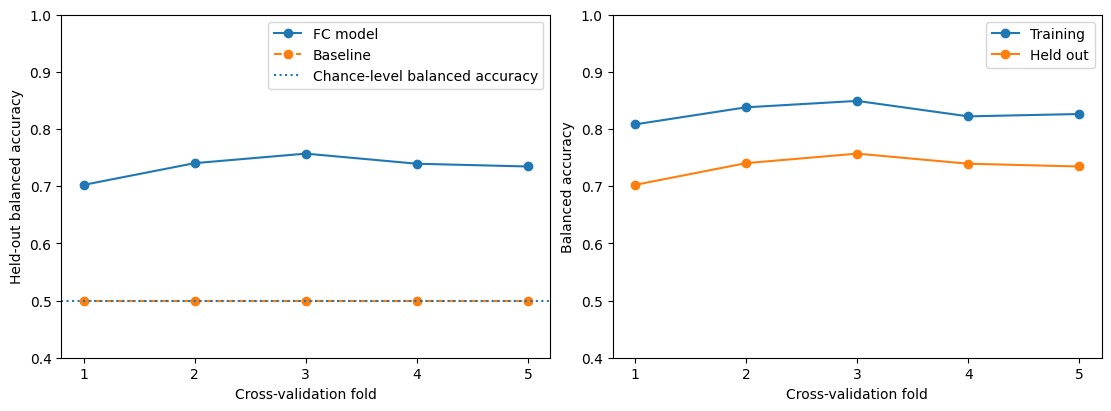

In [20]:
# Inspect how performance changes across folds and compare training with held-out scores.

folds = np.arange(1, cv.get_n_splits() + 1)

fig, axes = plt.subplots(1, 2, figsize=(11, 4), constrained_layout=True)

axes[0].plot(folds, model_cv["test_balanced_accuracy"], "o-", label="FC model")
axes[0].plot(folds, baseline_cv["test_balanced_accuracy"], "o--", label="Baseline")
axes[0].axhline(0.5, linestyle=":", label="Chance-level balanced accuracy")
axes[0].set(
    xlabel="Cross-validation fold",
    ylabel="Held-out balanced accuracy",
    xticks=folds,
    ylim=(0.4, 1.0),
)
axes[0].legend()

axes[1].plot(folds, model_cv["train_balanced_accuracy"], "o-", label="Training")
axes[1].plot(folds, model_cv["test_balanced_accuracy"], "o-", label="Held out")
axes[1].set(
    xlabel="Cross-validation fold",
    ylabel="Balanced accuracy",
    xticks=folds,
    ylim=(0.4, 1.0),
)
axes[1].legend()

plt.show()


### Reading the cross-validation results

In the original run of this notebook, the FC model's mean held-out balanced accuracy was approximately **0.735**, compared with **0.500** for the always-younger baseline. Ordinary accuracy was approximately 0.744 for the FC model, while the baseline already achieved about 0.690.

Your exact values should match if you use the same data, preprocessing, and fold split.

The fold-to-fold standard deviation tells us that performance changes depending on which people happen to be held out. It is a description of variability across these five folds; it is **not** a confidence interval, and the folds are not fully independent because their training sets overlap.

The second plot compares training and held-out balanced accuracy. If training performance is noticeably higher, that **train-test gap** is evidence that the model fits the training participants better than it generalizes to held-out participants. That is a sign of some overfitting.

Regularization and our 28-feature representation reduce overfitting risk, but they cannot guarantee that overfitting disappears.


## 11. One held-out prediction for every participant

The fold-level table tells us how each round performed. We may also want one prediction for every participant so that we can inspect the kinds of mistakes the model made.

`cross_val_predict` repeats the same train/test rotation but stores each person's prediction from the round in which that person was held out:

```text
person in Fold 1 -> prediction from model trained on Folds 2-5
person in Fold 2 -> prediction from model trained on Folds 1, 3, 4, 5
...
```

These are called **out-of-fold predictions**. Every prediction comes from a model that did not train on that participant.

We ask for `method="predict_proba"` because we want the model's estimated probability for each class. The output has two columns:

- column 0: probability of younger;
- column 1: probability of older.

`[:, 1]` selects the older-class probability.


accuracy             0.744
balanced accuracy    0.734
ROC AUC              0.796
Name: out-of-fold result, dtype: float64

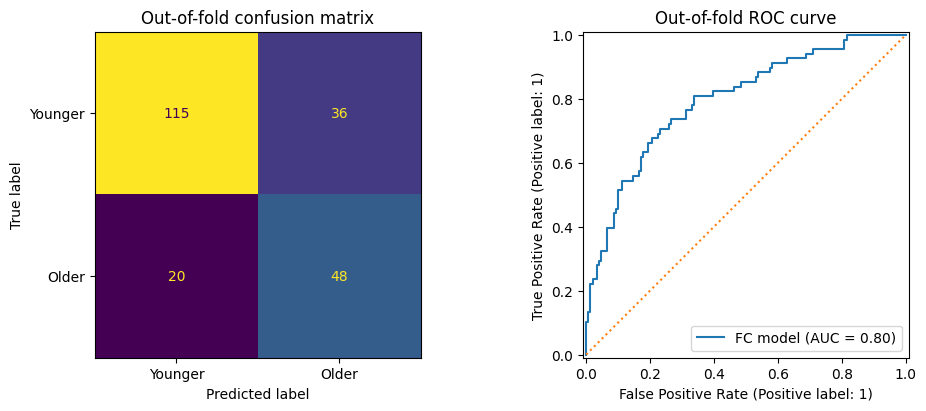

In [21]:
# Obtain one out-of-fold probability for every participant.

oof_probability = cross_val_predict(
    model,
    X,
    y,
    cv=cv,
    method="predict_proba",
)[:, 1]

# Convert probabilities into class labels using the default 0.50 threshold.
oof_prediction = (oof_probability >= 0.5).astype(int)

oof_metrics = pd.Series(
    {
        "accuracy": accuracy_score(y, oof_prediction),
        "balanced accuracy": balanced_accuracy_score(y, oof_prediction),
        "ROC AUC": roc_auc_score(y, oof_probability),
    },
    name="out-of-fold result",
)

display(oof_metrics.round(3))

fig, axes = plt.subplots(1, 2, figsize=(10, 4), constrained_layout=True)

ConfusionMatrixDisplay(
    confusion_matrix=confusion_matrix(y, oof_prediction),
    display_labels=["Younger", "Older"],
).plot(ax=axes[0], colorbar=False)
axes[0].set_title("Out-of-fold confusion matrix")

RocCurveDisplay.from_predictions(
    y,
    oof_probability,
    ax=axes[1],
    name="FC model",
)
axes[1].plot([0, 1], [0, 1], linestyle=":", label="Chance ranking")
axes[1].set_title("Out-of-fold ROC curve")

plt.show()


## 12. How to read the confusion matrix and ROC curve

### Confusion matrix: one threshold, four possible outcomes

The confusion matrix uses the 0.50 threshold and counts what happened.

Read it by **rows first**: the row is the participant's true group, and the column is the model's predicted group.

| | Predicted younger | Predicted older |
|---|---|---|
| **Actually younger** | correct younger prediction | younger participant incorrectly called older |
| **Actually older** | older participant incorrectly called younger | correct older prediction |

The two off-diagonal boxes are mistakes. Looking at them separately matters because a model can have similar overall accuracy while making very different kinds of errors.


### What does ROC AUC mean?

If you recall, our ML model will give out a probability score from 0 to 1, with higher score meaning that participant's FC is more likely to belong to an older person. 

Suppose we randomly pick two people:

- one older participant
- one younger participant

We then hide their true ages and look only at the model's scores.

If the model gives the **older participant the higher score**, it has ranked that pair correctly.

For example:

```text
                    Model's "older" score

Older participant          0.82
Younger participant        0.31

                    ✓ Correct ranking
```

But:

```text
                    Model's "older" score

Older participant          0.44
Younger participant        0.71

                    ✗ Incorrect ranking
```

Now imagine doing this for **every possible older–younger pair** in the dataset.

An ROC AUC of **0.80** means that, if you randomly select one older and one younger participant, there is about an **80% chance that the model assigns the older participant the higher score**.

This is different from accuracy because **we never had to choose a classification threshold** such as 0.50. We only asked whether the older person received a higher score.

That is why this statement is important:

> **AUC = 0.80 does not mean that 80% of participants were classified correctly.**

Accuracy asks:

> “After choosing a threshold, how often did the model give the correct class?”

ROC AUC instead asks:

> “Across possible thresholds, how well does the model generally rank older participants above younger participants?”


### What's the point of AUC?

The point of AUC is that a classifier usually produces a score or probability, and turning that score into “older” or “younger” requires choosing a threshold. Accuracy tells you how well the model performs at one particular threshold. AUC instead tells you whether the model has learned a useful signal for separating the two groups across possible thresholds.

In other words, ROC AUC tells us how well the FC-based model can distinguish older from younger participants, without tying our evaluation to one particular classification threshold.

And the rough conceptual anchors are:
- AUC = 0.50: the model's ranking is no better than chance.
- AUC > 0.50: older participants tend to receive higher “older” scores than younger participants.
- AUC = 1.00: every older participant receives a higher score than every younger participant.

So in our case of AUC = 0.8, if we randomly choose one older and one younger participant, the model will assign the older participant a higher “older” score about 80% of the time.


## 13. Is the observed performance better than chance label assignments?

Cross-validation tells us how well the model predicts held-out participants. A **permutation test** asks a different question:

> Would we see a score this high if the age labels had no real relationship with the FC features?

The idea is like repeatedly shuffling name cards:

1. keep each participant's 28 FC features exactly as they are;
2. randomly shuffle the age-group labels among participants;
3. rerun the full cross-validation procedure;
4. record the balanced accuracy;
5. repeat many times.

The shuffled runs create a reference distribution for what our evaluation procedure produces when the labels are deliberately disconnected from the FC data.

Our null hypothesis is:

> Network-level FC contains no more age-group information than expected under randomly reassigned age labels with this analysis procedure.

Here, let's use 5000 permutations. 


Observed balanced accuracy: 0.735
Permutation p-value: 0.0002


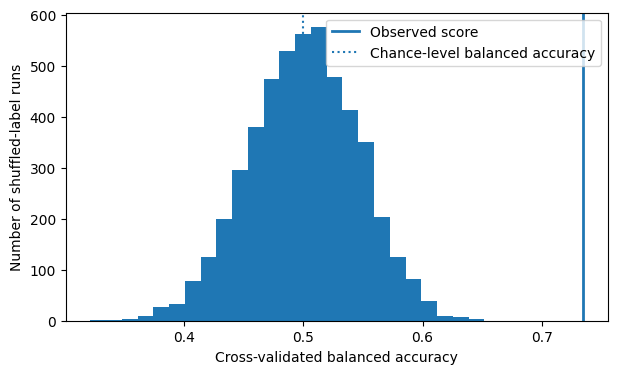

In [ ]:
# This cell refits many models because each shuffled-label run repeats cross-validation.

observed_score, permuted_scores, permutation_p = permutation_test_score(
    model,
    X,
    y,
    cv=cv,
    scoring="balanced_accuracy",
    n_permutations=5000,
    random_state=42,
    n_jobs=8, # 8 cores
)

print(f"Observed balanced accuracy: {observed_score:.3f}")
print(f"Permutation p-value: {permutation_p:.4f}")

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(permuted_scores, bins=25)
ax.axvline(observed_score, linewidth=2, label="Observed score")
ax.axvline(0.5, linestyle=":", label="Chance-level balanced accuracy")
ax.set(
    xlabel="Cross-validated balanced accuracy",
    ylabel="Number of shuffled-label runs",
)
ax.legend()
plt.show()


A small permutation *p*-value means that almost none of the shuffled-label runs reached a balanced accuracy as high as the observed one. That supports the claim that the observed predictive relationship is difficult to explain by random label assignment under this procedure.

It does **not** show that ageing causes the FC patterns, that the model would work clinically, or that it will generalize to a different dataset, scanner, site, or population.


## 14. Which FC features influenced the classifier?

Logistic regression gives one coefficient to each standardized feature.

Because the inputs are standardized, a one-unit increase means one **training-set standard deviation** for that feature.

Holding the other features fixed:

- a **positive coefficient** means higher values of that feature push the model toward a higher probability of the older class;
- a **negative coefficient** means higher values push toward the younger class;
- a coefficient farther from zero changes the weighted score more strongly per standardized unit.

But remember that cross-validation fits five different models. There is not one single coefficient vector during evaluation. We therefore collect the coefficients from each training fold and look at their average and variability.


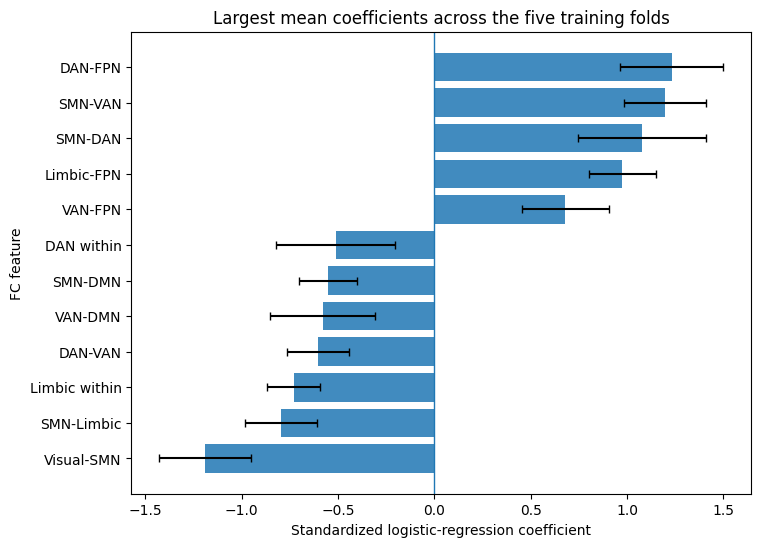

,mean coefficient,SD across folds
DAN-FPN,1.231,0.267
SMN-VAN,1.197,0.215
Visual-SMN,-1.189,0.237
SMN-DAN,1.078,0.333
Limbic-FPN,0.975,0.173
SMN-Limbic,-0.795,0.186
Limbic within,-0.730,0.137
VAN-FPN,0.679,0.226
DAN-VAN,-0.604,0.159
VAN-DMN,-0.579,0.271


In [23]:
# Fit the pipeline separately in each training fold and retain logistic-regression coefficients.

fold_coefficients = []

for train_index, test_index in cv.split(X, y):
    model.fit(X[train_index], y[train_index])

    # Inside the pipeline, scikit-learn names this step "logisticregression".
    coefficients = model.named_steps["logisticregression"].coef_[0]
    fold_coefficients.append(coefficients)

coefficient_df = pd.DataFrame(
    fold_coefficients,
    columns=feature_df.columns,
    index=[f"Fold {fold}" for fold in folds],
)

coefficient_summary = pd.DataFrame(
    {
        "mean coefficient": coefficient_df.mean(),
        "SD across folds": coefficient_df.std(ddof=1),
    }
)
coefficient_summary["absolute mean"] = coefficient_summary["mean coefficient"].abs()
coefficient_summary = coefficient_summary.sort_values("absolute mean", ascending=False)

top_features = coefficient_summary.head(12).sort_values("mean coefficient")

fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(
    top_features.index,
    top_features["mean coefficient"],
    xerr=top_features["SD across folds"],
    alpha=0.85,
    capsize=3,
)
ax.axvline(0, linewidth=1)
ax.set(
    xlabel="Standardized logistic-regression coefficient",
    ylabel="FC feature",
    title="Largest mean coefficients across the five training folds",
)
plt.show()

display(coefficient_summary.head(12).drop(columns="absolute mean").round(3))


### What can we learn from the coefficients?

Remember, here, our prediction goals are simply that whether patterns of FC distinguish younger from older participants. 

This is different than our previous tutorials, where we were trying to answer questions like "Which FC measures differ between the age groups?" or "How strongly is an FC measure associated with age?"

So, in thist tutorial, the  coefficients simply show which FC features the model uses, and in which direction, when distinguishing younger from older participants. Because we coded older participants as 1, positive coefficients mean that higher values of that FC feature push the model toward an older prediction, whereas negative coefficients mean that higher values push the model toward a younger prediction.  

For example, DAN–FPN connectivity has a relatively large positive coefficient, while Visual–SMN connectivity has a relatively large negative coefficient. These features therefore appear to contribute strongly to the model's predictions in opposite directions.  

This makes them interesting candidates for further investigation, but a large coefficient does not by itself show that a connection is biologically important for aging or that aging caused the difference. This is where we may need to do other analyses and also contextualize these findings within the literature to better understand what these results mean.

### Interpret coefficients carefully

Several cautions matter:

- FC features can be correlated with one another, so a coefficient can change when other features are present.
- L2 regularization intentionally shrinks coefficients.
- The error bars above show variation across fitted folds; they are **not** confidence intervals or hypothesis tests.
- A stable coefficient direction does not establish causality.
- Because sex composition differs across the age groups, some learned signal could reflect sex-related FC variation.



## 15. Think like a neuroscientist

Before writing a Discussion, ask what the model actually had the opportunity to learn.

1. **What is being predicted?** Two age cohorts, not exact age and not a continuous lifespan trajectory.
2. **What biological information is retained?** Mean FC within and between seven canonical networks.
3. **What information is discarded?** Individual edges, spatial variation within a network, time-varying connectivity, and non-FC measures.
4. **Could the model use a shortcut?** Group differences in sex composition, motion, data quality, or other variables could contribute to prediction.
5. **Where should the result generalize?** At most, to participants similar to this sample and processed in a similar way until independent external validation is performed.
6. **What does above-chance prediction mean?** The chosen FC representation contains information associated with the sampled age-group distinction that can be used for held-out classification under this evaluation procedure.
7. **What does it not mean?** It does not show that the FC differences cause ageing, that they change within individuals over time, or that the model is ready for clinical use.

## 16. Reporting the analysis

A concise Methods description could read:

> For each participant, Pearson-correlation FC matrices were Fisher *z*-transformed and summarized as seven within-network and 21 between-network mean-connectivity features. One participant without an age-group label was excluded. A scikit-learn pipeline standardized features within each training fold and fitted an L2-regularized logistic-regression classifier with balanced class weights. Performance was evaluated using five-fold stratified cross-validation with a fixed fold random seed. Evaluation metrics were balanced accuracy and ROC AUC. Performance was compared with a most-common-class baseline and assessed with a 5000-permutation label test.

A reproducible report should state participant counts, exclusions, feature construction, model settings, cross-validation strategy, random seed, evaluation metrics, baseline, permutation count, and permutation *p*-value.

Remember to report the results of all the folds. That would select the most favourable test subset after seeing the results.


## 17. Extend the analysis

Choose an extension because it answers a scientific question, not simply because another algorithm exists.

### Starting point

1. Remove `class_weight="balanced"`. Compare younger and older recall in the confusion matrix.
2. Replace the age-group target with a continuous phenotype such as `Hamilton_Scale`. This becomes a regression problem: handle missing targets, use a regression model such as `Ridge`, and evaluate held-out error rather than classification accuracy.

### Intermediate

3. Choose an appropriate ML technique where we can take all 4,950 unique edges as features. Look at the literature what ML techniques do people normally use for FC. See https://nilearn.github.io/stable/auto_examples/07_advanced/plot_age_group_prediction_cross_val.html 
4. Ask whether FC adds predictive information beyond sex/demographics by comparing a demographic-only model with FC-only model and FC-plus-demographic model using the same outer folds. 

### Advanced

5. Tune `C` using **nested cross-validation**. The inner loop chooses the hyperparameter using only the outer training data; the outer held-out fold remains untouched for evaluation. Seek help from the internet on how to run nested CV. 
6. Compare logistic regression with another classifier using identical outer folds and a pre-specified comparison plan.
7. Use graph theories measures as features to predict a phenotype! Look at the literature for inspiration. 


# Tutorial summary

The main outcome of this tutorial is understanding how ML can be appropriately applied to answer questions about neuroscience.

1. **Operationalize the question in ML terms:** each participant becomes one sample, the 28 FC summaries become features, and age group becomes the target.
2. **Understand the model:** logistic regression gives each feature a learned weight, adds the contributions into a score, and converts that score into a probability.
3. **Understand preprocessing:** `StandardScaler` calculates a mean and SD from training participants and expresses feature values in training-set SD units.
4. **Keep learning separate from evaluation:** held-out participants must not influence model fitting or learned preprocessing.
5. **Use pipelines:** the scaler and classifier stay together so cross-validation fits preprocessing only on the training folds.
6. **Use cross-validation:** five rounds allow every participant to receive one prediction from a model that did not train on that participant.
7. **Evaluate class imbalance carefully:** ordinary accuracy can look high even for a useless majority-class predictor, so balanced accuracy is more informative here.
8. **Read probabilities as well as class labels:** the confusion matrix evaluates one threshold; the ROC curve examines the trade-off across thresholds, and AUC summarizes ranking.
9. **Compare against simple alternatives:** a dummy baseline and permutation test help put model performance in context.
10. **Interpret cautiously:** prediction is not always equivalent to establishing causality, biological mechanism, clinical usefulness, or generalization to new populations.

## Short glossary

| Term | Meaning |
|---|---|
| **Sample** | one observation; here, one participant |
| **Feature** | an input measurement used by the model |
| **Target** | the outcome the model is asked to predict |
| **Fit / train** | learn parameters from training examples |
| **Transform** | apply a learned preprocessing rule to data |
| **Test / held out** | evaluate on examples not used for fitting |
| **Fold** | one subset of participants in cross-validation |
| **Pipeline** | a chain of preprocessing and model steps treated as one estimator |
| **Coefficient** | the weight logistic regression assigns to a feature |
| **Regularization** | a constraint that discourages unnecessarily extreme fitted coefficients |
| **Class weight** | a fitting weight that changes how strongly examples from each class affect the loss |
| **Leakage** | held-out information influencing training, preprocessing, or model choices |
| **Balanced accuracy** | average recall across classes |
| **ROC curve** | performance trade-off as the classification threshold moves |
| **ROC AUC** | summary of how well model scores rank the two classes across thresholds |
| **Generalization** | performance on examples not used to fit the model |
